In [1]:
from scipy.special import comb
import os
import pandas as pd
from statsmodels.stats.weightstats import ttest_ind
import numpy as np
from scipy.stats import mannwhitneyu
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
from scipy.stats import expon

import os
if 'COLAB_GPU' in os.environ:
  from google.colab import drive
  drive.mount("/content/drive/")

  path = "/content/drive/MyDrive/Estudios/ding/data"
  df = pd.read_csv(os.path.join(path, "Penn46_ascii.txt"), delimiter=" ")

else:
  df = pd.read_csv("data/Penn46_ascii.txt", delimiter = " ")

# Estratificación y Post-estratificación en Experimentos Aleatorizados

## Estratificación

<br>

En un experimento completamente aleatorizado, donde las unidades tienen una covariable discreta con $k$ estratos, es posible que la asignación de tratamiento y control genere un desbalance de dicha covariable, causando que sea difícil de interpretar los resultados del experimento ya que estos podrían ser atribuidos por el desbalance de la covariable o por el tratamiento.  


Para evitar esto, es posible utilizar un experimento aleatorizado estratificado (SRE).

<br>

**Definición: Experimento aleatorizado estratificado**

Considera un CRE con $n$ unidades. Adicionalmente, considera una covariable discreta $X_i \in \{ 1,...,K\}$ donde podemos definir el número y proporción de unidades de cada estrato como  $n_{[k]} = \#\{i:X_i=k\}$ y $\pi_{[k]}=n_{[k]}/n$, respectivamente.

El número de unidades del estrato $k$ asignadas al tratamiento ($n_{[k]1}$) y al control ($n_{[k]0}$) es:

$$n_{[k]1}=\#\{i:X_i=k, Z_i = 1\}$$
$$n_{[k]0}=\#\{i:X_i=k, Z_i = 0\}$$

<br>

Consideremos estas unidades como fijas. Un SRE es un experimento en el que se conducen $K$ CRE independientes dentro de los K estratos de la covariable discreta $X$.

<br>

El número total de aleatorizaciones posibles es:

$$\prod_{i=1}^k\binom{n_{[k]}}{n_{[k]1}} < \binom{n}{n_1}$$

<br>

**Definición: Propensity score**

El propensity score es la proporción de unidades de cada estrato que reciben el tratamiento:

$$e_{[k]}=\frac{n_{[k]1}}{n_{[k]}}$$

- $e_{[k]}$ es fijo en un SRE pero aleatorio en un CRE.

**Definición: Efectos causales promedio del estrato y efecto causal promedio global**

Recordemos que el efecto causal para cada unidad $i$ es $\tau_i = Y_i(1) - Y_i(0)$. Para cada estrato $k$, podemos definir el efecto causal promedio:

$$\tau_{[k]} = n_{[k]}^{-1}\sum_{X_i=k}\tau_i$$

El efecto causal promedio global es el promedio ponderado de los efectos causales promedios de cada estrato, donde el ponderador es la proporción de unidades del estrato.

$$\tau=\sum_{k=1}^K\pi_{[k]}\tau_{[k]}$$

## Prueba de aleatorización de Fisher en Experimentos Estratificados Aleatorizados

Recordemos que la hipótesis nula de Fisher es que los efectos potenciales de la unidad $i$ son iguales:

$$H_{0F}:Y_i(1) =Y_i(0) \text{ para todas las unidades i = 1,...,n}$$

<br>

En el caso estratificado, podemos usar cualquier estadístico $T=T(Z,Y,X)$ donde $Z$ es el vector de tratamiento, $Y$ es el vector de resultados observados y $X$ es la matriz de covariadas. Bajo un SRE y $H_{0F}$ el estadístico T tiene una distribución conocida porque la distribución de $Z$ es conocida. En este caso, debemos obtener la distribución del vector de tratamiento a través de permutaciones en cada estrato, es decir, obtener la distribución condicional de $Z | X_i = k$. A esta prueba se le conoce como prueba de aleatorización condicional o prueba de permutación condicional.

<br>

**Estimador estratificado**

Cuando estratificamos, es posible obtener el estimador estratificado del efecto causal promedio $\hat\tau_S$:

$$\hat\tau_S = \sum_{k=1}^K\pi_{[k]}\hat\tau_{[k]}$$

Donde $\hat\tau_{[k]}$ es el estimador del efecto causal promedio del estrato $k$:

$$\hat\tau_{[k]} = n_{[k]1}^{-1}\sum_{i=1}^{n}I(Z_i=1, X_i=k)Y_i - n_{[k]0}^{-1}\sum_{i=1}^{n}I(Z_i=0, X_i=k)Y_i$$

<br>

**Estimador estratificado studentizado**

La versión studentizada del estimador del efecto causal promedio estratificado está dado por:

$$t_S=\frac{\hat\tau_S}{\sqrt{\hat V_S}}$$

Donde $\hat V_S$ es el estimador estratificado de la varianza, asumiendo que no hay correlación entre los estratos:

$$\hat V_S= \sum_{k=1}^K\pi_{[k]}^2\bigg(\frac{\hat S_{[k]}^2(1)}{n_{[k]1}}  + \frac{\hat S_{[k]}^2(0)}{n_{[k]0}}\bigg)$$


y en donde $S_{[k]}^2(1) \text{ y }S_{[k]}^2(0)$ son las varianzas muestrales de los resultados bajo tratamiento y control, respectivamente.

<br>

**Prueba de Wilcoxon para suma de rangos**

Para la prueba de Wilcoxon es posible calcular un valor estratificado $W_S$ mediante la suma ponderada de los estadísticos en cada estrato $W_{[k]}$:

$$W_S = \sum_{k=1}^Kc_{[k]}W_{[k]}$$

Aquí no se discute el cálculo del ponderador, sin embargo, pueden usarse dos:

 - $c_{[k]}=\frac{1}{n_{[k]1}n_{[k]0}}$

 - $c_{[k]}=\frac{1}{n_{[k]}+1}$

<br>

**Prueba de Kolmogorov-Smirnoff**

Podemos computar el estadístico estratificado $D_S$ como la suma ponderada de las diferencias máximas de las distribuciones empíricas de los resultados bajo tratamiento y control en cada estrato $D_{[k]}$:

$$D_S=\sum_{k=1}^Kc_{[k]}D_{[k]}$$

Donde:

$$c_{[k]}= \sqrt{n_{[k]1}n_{[k]0} / n_{[k]}}$$



In [2]:
# Penn data

z = df["treatment"]
y = np.log(df["duration"])
block = df["quarter"]

# Creamos una tabla de contingencia
pd.crosstab(z, block)

quarter,0,1,2,3,4,5
treatment,,,,,,
0,234,41,687,794,738,860
1,87,48,757,866,811,461


In [3]:
def stat_sre(z, y, x):
  xlevels = np.unique(x)
  K = len(xlevels)
  Pi_K = np.zeros(K)
  Tau_K = np.zeros(K)
  W_K = np.zeros(K)

  for k in range(K):
    x_k = xlevels[k]
    z_k = z[x==x_k]
    y_k = y[x==x_k]
    Pi_K[k] = len(z_k)/len(z)
    Tau_K[k] = np.mean(y_k[z_k==1]) - np.mean(y_k[z_k==0])
    W_K[k] = mannwhitneyu(y_k[z_k==1], y_k[z_k==0]).statistic

  return [np.sum(Pi_K * Tau_K), np.sum(W_K / Pi_K)]


In [4]:
stats_obs = stat_sre(z, y, block)
stats_obs

[np.float64(-0.0899064590011073), np.float64(4687961.229438581)]

In [5]:
def zRandomSRE(z, x):
  xlevels = np.unique(x)
  K = len(xlevels)
  zrandom = z.copy()
  for k in range(K):
    x_k = xlevels[k]
    zrandom[x==x_k] = np.random.permutation(z[x==x_k])

  return zrandom

In [6]:
MC = 1000
statSREMC = np.zeros((MC, 2))
print(statSREMC.shape)
for mc in range(MC):
  zrandom = zRandomSRE(z, block)
  statSREMC[mc, ] = stat_sre(zrandom, y, block)

(1000, 2)


In [7]:
print(np.mean(statSREMC[:,0] <= stats_obs[0]))
print(np.mean(statSREMC[:,1] <= stats_obs[1]))

0.001
0.0


## Inferencia Neymaniana



En un SRE consideramos k CRE independientes. Basado en esto, podemos extender los resultados de Neyman a los SRE. En cada estrato $k$, el estimador de diferencia de medias $\hat \tau_{[k]}$ es insesgado para $\tau_{[k]}$ con varianza:

$$var(\hat\tau_{[k]})= \frac{S^2_{[k]}(1)}{n_{[k]1}} + \frac{S^2_{[k]}(0)}{n_{[k]0}} - \frac{S^2_{[k]}(\tau)}{n_{[k]}}$$

Donde $S^2_{[k]}(1)$, $S^2_{[k]}(0)$ y $S^2_{[k]}(\tau)$ son las varianzas dentro del estrato k de los resultados potenciales de tratamiento y control, así como de los efectos causales individuales, respectivamente. Por lo tanto, el estimador de diferencia de medias $\hat \tau$ es el promedio ponderado de los estimadores de cada estrato:

$$\hat \tau = \sum_{k=1}^{K} \pi_{[k]} \hat \tau_{[k]}$$

Y la varianza de dicho estimador es (recordando que los CRE son independientes):

$$var(\hat \tau_{[k]}) = \sum_{k=1}^{K} \pi_{[k]}^2 var(\hat \tau_{[k]})$$

Si $n_{[k]1} \geq 2$ y $n_{[k]0} \geq 2$ podemos obtener las varianzas muestrales $\hat S^2_{[k]}(1)$ y $\hat S^2_{[k]}(0)$ y construir el estimador conservador $\hat V_S$:

$$\hat V_S = \sum_{k=1}^K\pi_{[k]}^2\bigg(\frac{\hat S^2_{[k]}(1)}{n_{[k]1}} + \frac{\hat S^2_{[k]}(0)}{n_{[k]0}}  \bigg)$$

Con los resultados anteriores podemos construir intervalos de confianza para $\hat \tau_S$ de tipo Wald $1-\alpha$ para $\tau$:

$$\hat \tau \pm z_{1-\alpha / 2} \sqrt{\hat V_S}$$

0.002649471619353108
0.0026387056721032705
0.0001257350167121581
0.00012686543897443353


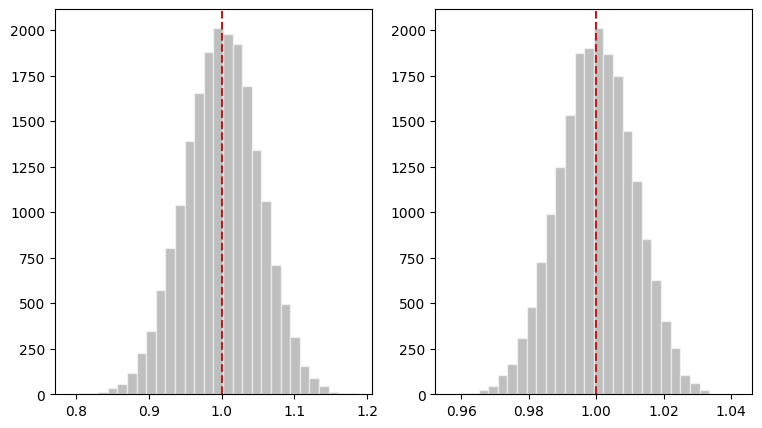

In [44]:
# En este ejemplo ilustraremos la inferencia de Nayman cuando tenemos
# pocos estratos pero grandes y cuando tenemos muchos estratos pero pequeños

def neyman_SRE(z,y,x):
    """
    Función para computar los estimadores puntuales y varianzas de Neyman en un SRE
    """
    xlevels = np.unique(x)
    K = len(xlevels)
    PiK = np.zeros(K)
    TauK = np.zeros(K)
    VarK = np.zeros(K)

    for k in range(K):
        xk = xlevels[k] # Estrato k
        zk = z[x==xk] # Vector de tratamiento en el estrato k
        yk = y[x==xk] # Vector de resultados observados en el estrato k

        PiK[k] = len(zk)/len(z)
        TauK[k] = np.mean(yk[zk==1]) - np.mean(yk[zk==0])
        VarK[k] = np.var(yk[zk==1], ddof=1) / np.sum(zk) + np.var(yk[zk==0], ddof=1) / np.sum( 1- zk)
        
    return [np.sum(PiK*TauK), np.sum((PiK**2)*VarK)]

K = 5
n = 80
n1 = 50
n0 = 30
x = np.repeat(np.arange(0, K), n)
y0 = expon.rvs(scale = 1/(x+1), size=n*K)
y1 = y0 + 1
zb = np.concatenate([np.ones(n1), np.zeros(n0)])

MC = int(20000)
Tauhat = np.zeros(MC)
Varhat = np.zeros(MC)

for mc in range(MC):
    z = np.concatenate([np.random.permutation(zb) for i in range(K)])
    y = z*y1 + (1-z)*y0
    est = neyman_SRE(z,y,x)
    Tauhat[mc] = est[0]
    Varhat[mc] = est[1]


fig, ax = plt.subplots(ncols=2, figsize =(9,5))
ax[0].hist(Tauhat, bins=30, color = "grey", edgecolor='white', alpha = 0.5)
ax[0].axvline(x = np.mean(Tauhat), color = "firebrick", linestyle='--')


print(np.var(Tauhat, ddof=1))
print(np.mean(Varhat))

K = 50
n = 8
n1 = 5
n0 = 3
x = np.repeat(np.arange(0, K), n)
y0 = expon.rvs(scale = 1/(x+1), size=n*K)
y1 = y0 + 1
zb = np.concatenate([np.ones(n1), np.zeros(n0)])

MC = int(20000)
Tauhat = np.zeros(MC)
Varhat = np.zeros(MC)

for mc in range(MC):
    z = np.concatenate([np.random.permutation(zb) for i in range(K)])
    y = z*y1 + (1-z)*y0
    est = neyman_SRE(z,y,x)
    Tauhat[mc] = est[0]
    Varhat[mc] = est[1]


ax[1].hist(Tauhat, bins=30, color = "grey", edgecolor='white', alpha = 0.5)
ax[1].axvline(x = np.mean(Tauhat), color = "firebrick", linestyle='--')


print(np.var(Tauhat, ddof=1))
print(np.mean(Varhat))

## Post-estratificación en un CRE

En un SRE, usamos la covariable $X$ en la etapa de diseño. Si ocupáramos $X$ en la etapa de análisis, entonces el experimento se llamaría post-estratificación. Asintóticamente, los estimadores de ambos mecanismos son pequeños cuando consideramos estratos grandes.

Para entender un experimento con post-estratificación, consideremos que en un CRE con una covariada discreta $X$, el número de unidades recibiendo el tratamiento y control es aleatorio en cada estrato $k$ porque la elección de z no depende del número de unidades de cada estrato. Si fijaramos el número de unidades que reciben tratamiento y control en cada estrato, entonces obtenemos un SRE. Pero si condicionáramos en el vector de tamaño $k\times2$, $\bold n=\{n_{[k]1},n_{[k]0}\}$, entonces el CRE se convierte en un SRE. Esto es, si ninguno de los componentes de $\bold n$ es cero, entonces:

$$pr_{CRE}(Z=z|n)=\frac{pr_{CRE}(Z=z,\bold n)}{pr_{CRE}(\bold n)}= \frac{1}{\prod_{i=1}^{k}\binom{n_[k]}{n_{[k]1}}}$$


Es decir, podemos obtener resultados asintóticamente similares a un SRE condicionando posterior al experimento sobre $\bold n$.

En particular, el FRT se convierte en un FRT *condicional* y el análisis de Neyman se convierte en *post-estratificación*, donde el estimador de diferencia de medias es:

$$\hat \tau_{PS}= \sum_{k=1}^{K}\pi_{[k]}\hat \tau_{[k]}$$

el cuál tiene una forma idéntica al estimador de SRE. La varianza de $\hat \tau_{PS}$ condicionando en $\bold n$ es idéntica a la varianza de $\hat \tau_{S}$ bajo el SRE.

In [63]:
df = pd.read_stata("data/Chong-et-al-Final-Data-Set.dta")
#print(pd.crosstab(df["treatment"], df["class_level"]))

cols = ["treatment", "gradesq34", "class_level", "anemic_base_re"]

df = df[cols]
df = df.loc[df["treatment"] != "Soccer Player"]

# Realizamos tablas de contingencia todas las unidades
df["z"] = np.where(df["treatment"]=="Physician",1,0)
df["y"] = df["gradesq34"]
df["x"] = np.where(df["anemic_base_re"]=="Yes",1,0)


print("-"*50)
print("Tabla de contingencia de todas las unidades")
print(pd.crosstab(df["z"], df["class_level"]))

print("-"*50)
print("Tabla de contingencia de unidades con anemia")
print(pd.crosstab(df.loc[df["anemic_base_re"]=="Yes","z"], df["class_level"]))

print("-"*50)
print("Tabla de contingencia de unidades sin anemia")
print(pd.crosstab(df.loc[df["anemic_base_re"]=="No","z"], df["class_level"]))

# Usamos la función neyman_sre para obtener el estimador estratificado
print("-"*50)
est_sre = neyman_SRE(df["z"], df["y"], df["class_level"])
print("Estimador estratificado (diferencia de medias):", np.round(est_sre[0], 3))
print("Desviación estándar (diferencia de medias):", np.round(np.sqrt(est_sre[1]), 3))
print("Estadístico t:", np.round(est_sre[0]/np.sqrt(est_sre[1]),3))

# Ahora usamos post-estratificación
print("-"*50)
df["sps"] = df["class_level"].astype(str) + df["x"].astype(str)
est_sps = neyman_SRE(df["z"], df["y"], df["sps"])
print("Estimador post_estratificado (diferencia de medias):", np.round(est_sps[0], 3))
print("Desviación estándar (diferencia de medias):", np.round(np.sqrt(est_sps[1]), 3))
print("Estadístico t:", np.round(est_sps[0]/np.sqrt(est_sps[1]),3))

--------------------------------------------------
Tabla de contingencia de todas las unidades
class_level  1.0  2.0  3.0  4.0  5.0
z                                   
0             15   19   16   12   10
1             17   20   15   11   10
--------------------------------------------------
Tabla de contingencia de unidades con anemia
class_level  1.0  2.0  3.0  4.0  5.0
z                                   
0              9    5    4    5    6
1              9    8    6    6    4
--------------------------------------------------
Tabla de contingencia de unidades sin anemia
class_level  1.0  2.0  3.0  4.0  5.0
z                                   
0              6   14   12    7    4
1              8   12    9    5    6
--------------------------------------------------
Estimador estratificado (diferencia de medias): 0.406
Desviación estándar (diferencia de medias): 0.202
Estadístico t: 2.005
--------------------------------------------------
Estimador post_estratificado (diferencia d